# Data Analysis Workflow

## 1 Data Understanding
**Tujuan:** Memahami struktur dan karakteristik awal data.

Langkah:
- Baca file dataset dan pahami tiap variabel
- Cek tipe data tiap kolom 
- Ubah tipe data jika diperlukan
- Identifikasi tipe variabel, seperti:
  - Kategorikal
  - Numerikal 


## 2 Exploratory Data Analysis (EDA) — Sebelum Imputasi
**Tujuan:** Mengetahui kondisi data mentah, distribusi, outlier, dan korelasi.

## 3 Data Cleaning & Imputasi
**Tujuan:** Menyiapkan data agar siap diolah.

## 4 EDA Setelah Imputasi
**Tujuan:** Mengetahui hubungan antar variabel setelah diubah dan persiapan modelling

# Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gapminder.csv')
df.head()

,Unnamed: 0,country,continent,year,lifeExp,pop,gdpPercap
0,1,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,2,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,3,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,4,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,5,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690 entries, 0 to 1689
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1690 non-null   int64  
 1   country     1690 non-null   object 
 2   continent   1690 non-null   object 
 3   year        1690 non-null   int64  
 4   lifeExp     1690 non-null   float64
 5   pop         1690 non-null   int64  
 6   gdpPercap   1690 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 92.5+ KB


In [4]:
df.describe()

,Unnamed: 0,year,lifeExp,pop,gdpPercap
count,1690.000000,1690.000000,1690.000000,1.690000e+03,1690.000000
mean,845.500000,1979.437870,59.372952,2.965061e+07,6730.380327
std,488.005294,17.222054,12.898419,1.063649e+08,7927.918278
min,1.000000,1952.000000,23.599000,6.001100e+04,241.165876
25%,423.250000,1963.250000,48.123000,2.820552e+06,1191.672949
50%,845.500000,1977.000000,60.445500,7.150606e+06,3481.093749
75%,1267.750000,1992.000000,70.803750,1.976247e+07,9122.163458
max,1690.000000,2007.000000,82.603000,1.318683e+09,39724.978670


In [5]:
df.isnull().sum()

Unnamed: 0    0
country       0
continent     0
year          0
lifeExp       0
pop           0
gdpPercap     0
dtype: int64

In [6]:
df.isna().sum()

Unnamed: 0    0
country       0
continent     0
year          0
lifeExp       0
pop           0
gdpPercap     0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.columns

Index(['Unnamed: 0', 'country', 'continent', 'year', 'lifeExp', 'pop',
       'gdpPercap'],
      dtype='object')

# EDA

## Pie Chart

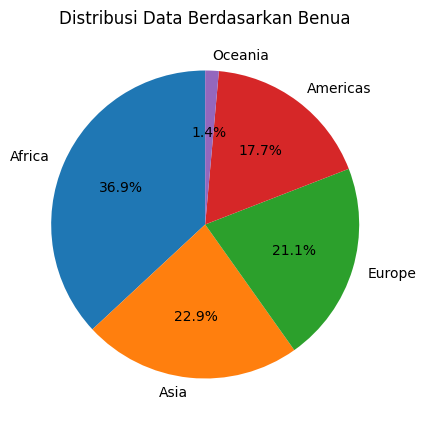

In [9]:
# Pie chart sederhana untuk distribusi benua
continent_counts = df['continent'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(continent_counts, labels=continent_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Berdasarkan Benua")
plt.show()

## Box Plot

fungsi dari boxplot :

1. Melihat distribusi data
2. Melihat penyebaran/keragaman data (termasuk pesebaran pengamatan outlier)
3. Melihat kesimetrisan data

Keunggulan Boxplots dibanding dengan Histogram dan stemplot → Boxplot lebih praktis pada saat kita ingin membandingkan **sebaran** beberapa kelompok data secara bersamaan

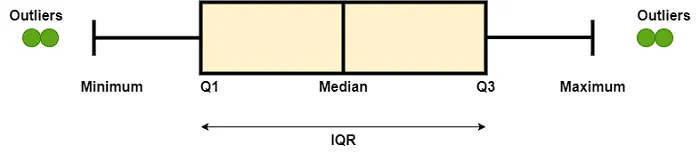

- **IQR** :  menyajikan interquartile range (IQR), dimana 50 % dari nilai data pengamatan terletak di sana. semakin panjang bidang IQR menunjukkan data semakin menyebar
- **Whiskers** : whiskers bawah/kiri menunjukkan nilai yang lebih rendah dari kumpulan data yang berada dalam IQR. Whiskers atas/kanan menunjukkan nilai yang lebih tinggi dari kumpulan data yang berada dalam IQR. Masing-masing garis whisker dimulai dari ujung kotak IQR, dan berakhir pada nilai data yang bukan dikategorikan sebagai outlier

### Basic Bloxplot

<Axes: >

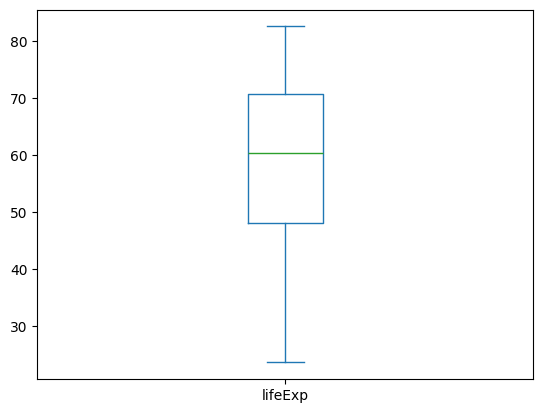

In [10]:
# menggunakan panda
df['lifeExp'].plot(kind='box')

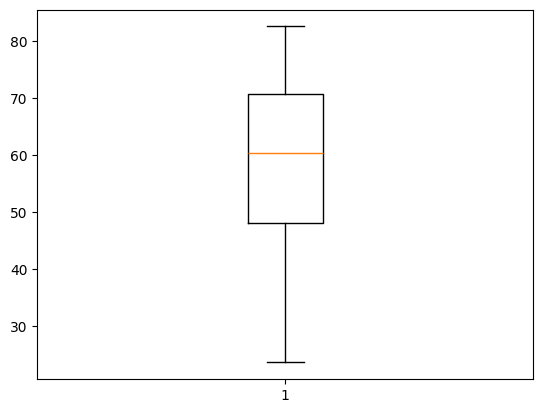

In [11]:
# menggunakan matplotlib
plt.boxplot(df['lifeExp'])
plt.show()

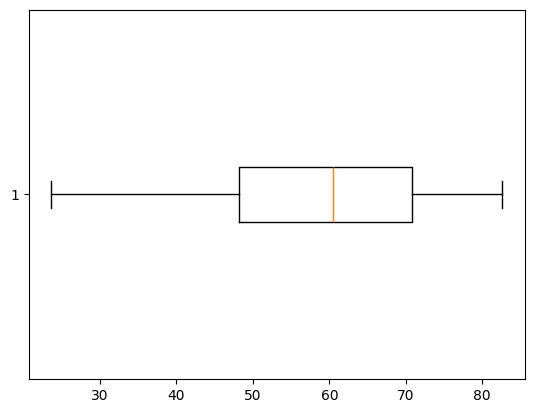

In [12]:
# menggunakan matplotlib, tapi horizontal
plt.boxplot(df['lifeExp'], vert=False)
plt.show()

## Boxplot With Multiple Plots

<Axes: title={'center': 'lifeExp'}, xlabel='continent'>

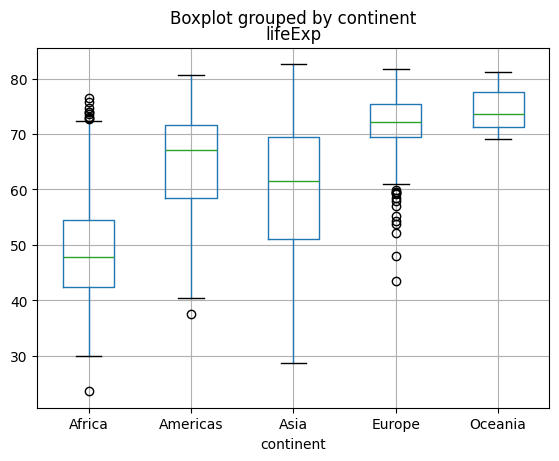

In [13]:
# menggunakan panda
df.boxplot(column = 'lifeExp', by = 'continent')

In [14]:
# Cek unique value dari variabel continents
df['continent'].unique()

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_26631/3363488373.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_continent, labels=continents)


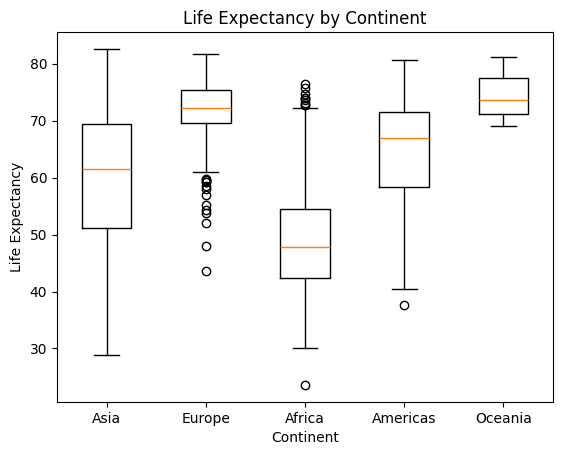

In [15]:
# mengambil unique value dari variabel continents
continents = df['continent'].unique()

# ngambil data data lifeExp untuk setiap continent
data_by_continent = [df.loc[df['continent'] == continent, 'lifeExp'].values for continent in continents]

# Membuat boxplot untuk setiap continent
plt.boxplot(data_by_continent, labels=continents)

plt.title('Life Expectancy by Continent')
plt.ylabel('Life Expectancy')
plt.xlabel('Continent')

plt.show()

## Line Chart

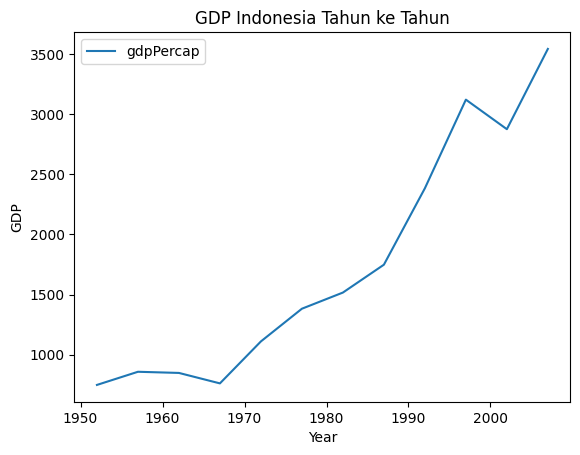

In [16]:
# using pandas
# ngambil data indonesia aja
gdp_indonesia = df[df['country'] == 'Indonesia'][['year', 'gdpPercap']]

# mengurutkan data
gdp_indonesia.sort_values('year', inplace=True)

gdp_indonesia.plot(kind='line', x='year', y='gdpPercap')

plt.title('GDP Indonesia Tahun ke Tahun')
plt.xlabel('Year')
plt.ylabel('GDP')

plt.show()

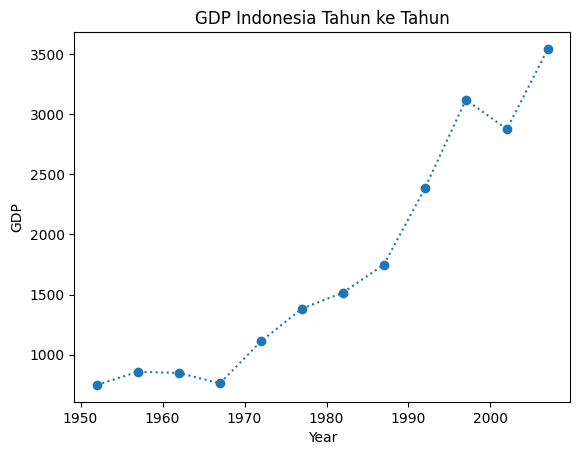

In [17]:
# using matplotlib
# ngambil data indonesia aja
gdp_indonesia = df[df['country'] == 'Indonesia'][['year', 'gdpPercap']]

# mengurutkan data
gdp_indonesia.sort_values('year', inplace=True)

plt.plot(gdp_indonesia['year'], gdp_indonesia['gdpPercap'], marker = 'o', linestyle = 'dotted')

plt.title('GDP Indonesia Tahun ke Tahun')
plt.xlabel('Year')
plt.ylabel('GDP')

plt.show()

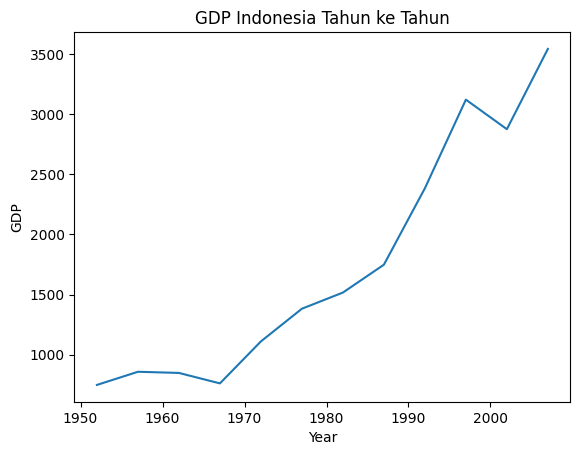

In [18]:
# using seaborn
# ngambil data indonesia aja
gdp_indonesia = df[df['country'] == 'Indonesia'][['year', 'gdpPercap']]

# mengurutkan data
gdp_indonesia.sort_values('year', inplace=True)

sns.lineplot(data=gdp_indonesia, x='year', y='gdpPercap')

plt.title('GDP Indonesia Tahun ke Tahun')
plt.xlabel('Year')
plt.ylabel('GDP')

plt.show()

## Scatter Plot

"\nax.set_xlabel('GDP per Capita')\nax.set_ylabel('Life Expectancy')\nax.set_title('Life Expectancy vs. GDP per Capita in 2002')\n\nplt.show()\n"

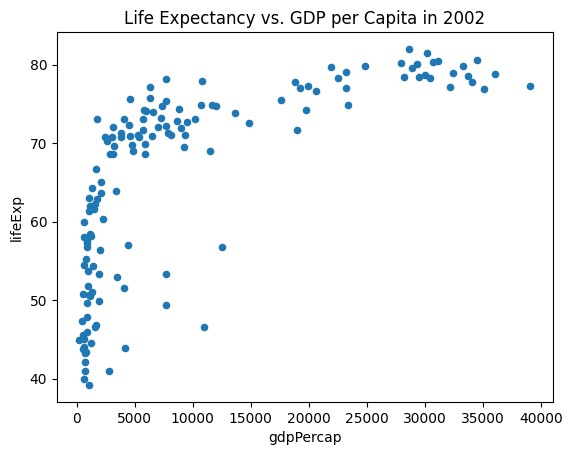

In [19]:
# using pandas
# ambil data 2002 aja
year_2002 = df[df['year'] == 2002][['gdpPercap', 'lifeExp']]
# ax = year_2002.plot.scatter(x='gdpPercap', y='lifeExp')

year_2002.plot.scatter(x='gdpPercap', y='lifeExp', title = 'Life Expectancy vs. GDP per Capita in 2002')

"""
ax.set_xlabel('GDP per Capita')
ax.set_ylabel('Life Expectancy')
ax.set_title('Life Expectancy vs. GDP per Capita in 2002')

plt.show()
"""

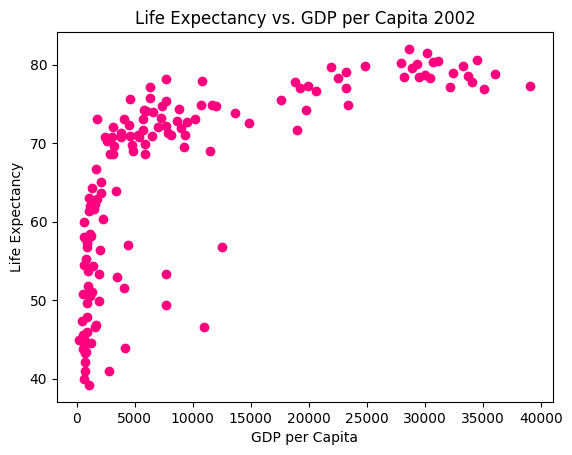

In [20]:
# using matplotlib
#ambil data 2002 aja
year_2002 = df[df['year'] == 2002][['gdpPercap', 'lifeExp']]

plt.scatter(year_2002['gdpPercap'], year_2002['lifeExp'], color='#FF007F')

plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy vs. GDP per Capita 2002')

plt.show()

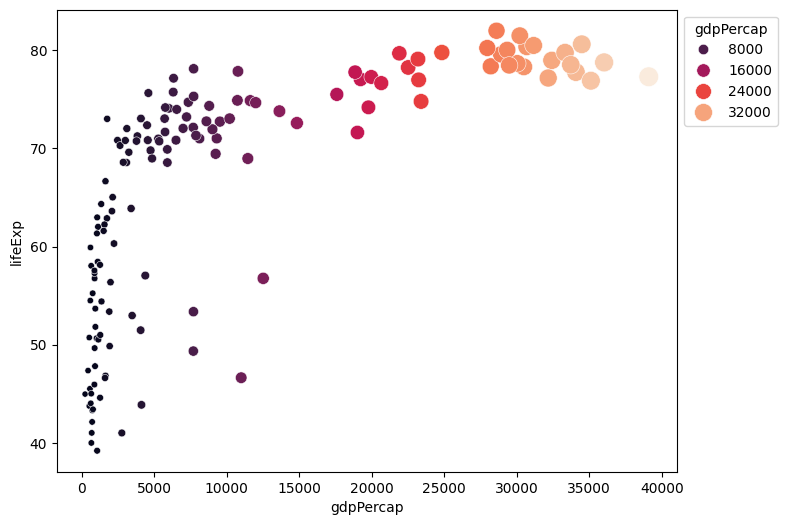

In [21]:
# Ambil data tahun 2002 saja
year_2002 = df[df['year'] == 2002][['gdpPercap', 'lifeExp']]

# Plot scatterplot
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    x='gdpPercap', 
    y='lifeExp', 
    data=year_2002, 
    hue='gdpPercap', 
    palette="rocket",
    size='gdpPercap', 
    sizes=(20, 200), 
    legend='brief'
)
scatter.legend(title='gdpPercap', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

## Heat Map

Heat map adalah representasi visual dari data yang memanfaatkan warna untuk menggambarkan nilai-nilai dalam suatu matriks. Setiap sel dalam matriks direpresentasikan oleh warna yang mencerminkan nilai numeriknya, tetapi umunya digunakan untuk menentukan nilai kolerasi antar variabel.

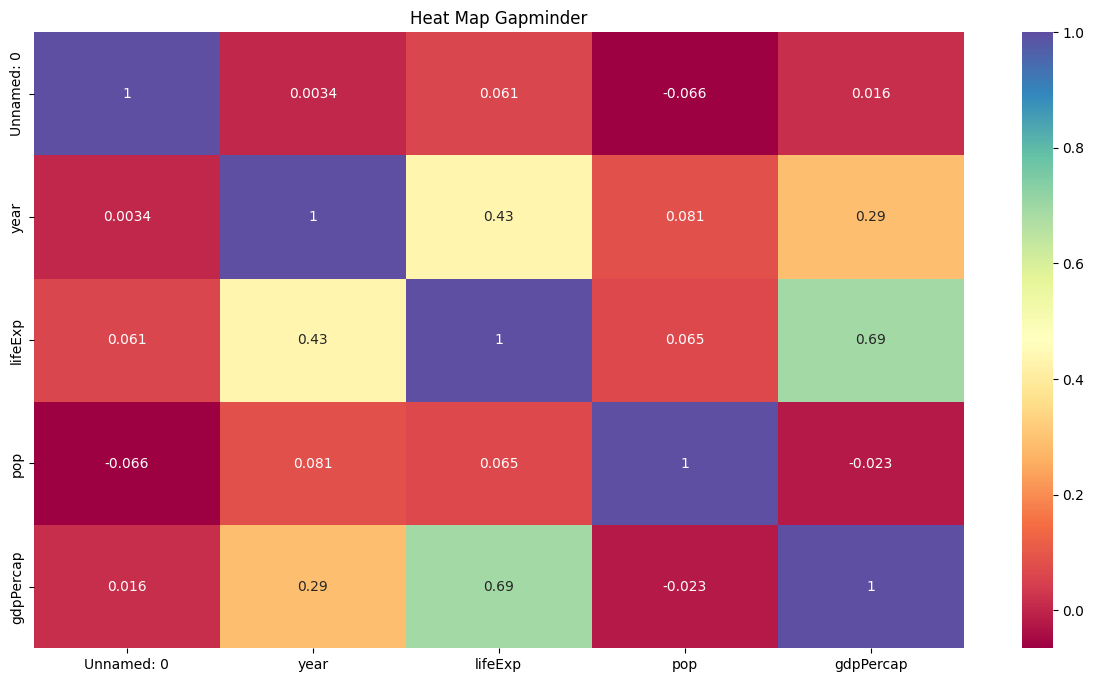

In [22]:
# Hanya gunakan kolom numerik
df_corr = df.select_dtypes(include=[np.number]).corr()

# Heat Map
plt.figure(figsize=(15,8))
sns.heatmap(df_corr,xticklabels=df_corr.columns,yticklabels=df_corr.columns,annot=True, 
            cmap="Spectral").set(title='Heat Map Gapminder') 
plt.show()

# Bar Chart

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_26631/1499596781.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='continent', y='pop', palette='viridis')


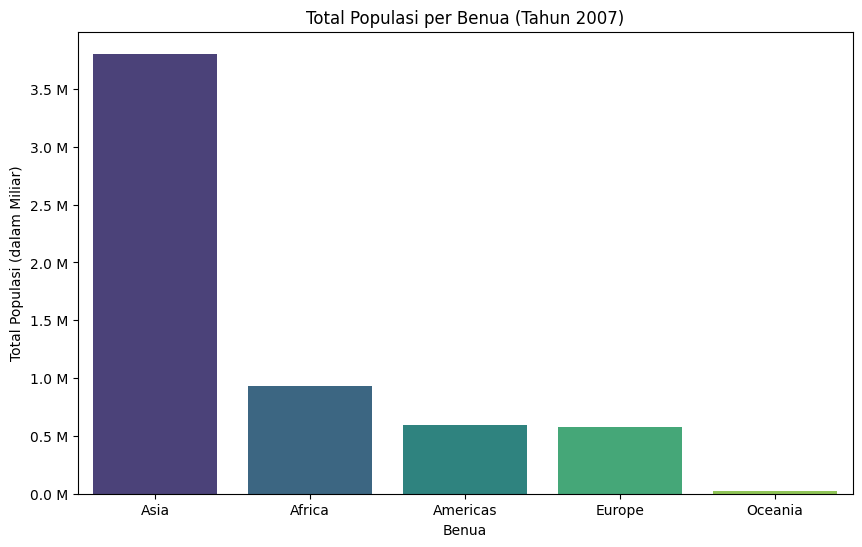

In [23]:
most_recent_year = df['year'].max()

# Filter data untuk tahun terbaru
df_recent = df[df['year'] == most_recent_year]

# Group berdasarkan benua dan hitung total populasi
df_grouped = df_recent.groupby('continent')['pop'].sum().reset_index()

# Urutkan data agar bar chart rapi (dari terbesar ke terkecil)
df_grouped = df_grouped.sort_values('pop', ascending=False)

# Buat Bar Chart menggunakan Seaborn
plt.figure(figsize=(10, 6)) # Atur ukuran gambar
sns.barplot(data=df_grouped, x='continent', y='pop', palette='viridis')

# Atur Judul dan Label
plt.title(f'Total Populasi per Benua (Tahun {most_recent_year})')
plt.xlabel('Benua')
plt.ylabel('Total Populasi (dalam Miliar)')
    
# Menambahkan formatting agar sumbu Y lebih mudah dibaca
# Fungsi ini akan mengubah angka (misal 3800000000) jadi '3.8 M'
def format_billions(x, pos):
    'Fungsi untuk format angka jadi Miliar'
    return f'{x*1e-9:.1f} M'
    
formatter = plt.FuncFormatter(format_billions)
plt.gca().yaxis.set_major_formatter(formatter)

# Visualisasi Multivariat

In [24]:
import pandas as pd
import seaborn as sns

In [25]:
# Baca data iris dari file CSV
iris = pd.read_csv("Iris.csv")
print(iris.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


## Join Plot

Join plot memungkinkan untuk melihat pola atau tren yang mungkin ada dalam data, seperti korelasi positif atau negatif antara variabel-variabel tersebut. Selain itu, join plot juga dapat memberikan informasi tentang sebaran data dan kepadatan titik di sepanjang sumbu.

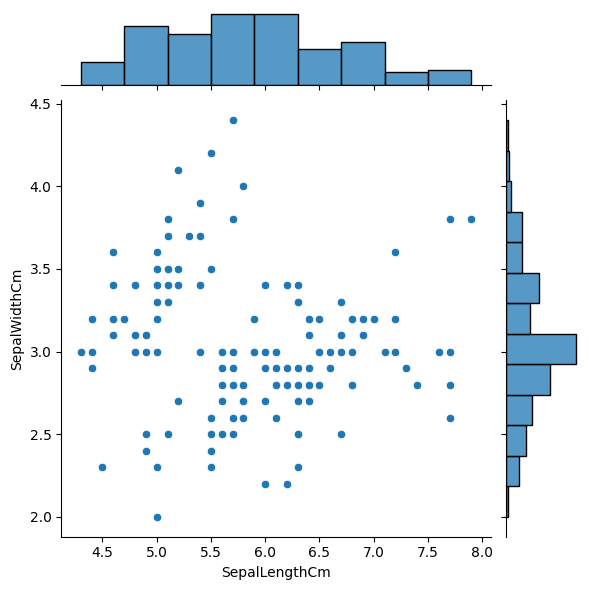

In [26]:
# A seaborn jointplot shows bivariate scatterplots and univariate histograms in the same figure
sns.jointplot(x="SepalLengthCm", y="SepalWidthCm", data=iris)

# Pair Plot

Pair plot adalah jenis grafik yang digunakan dalam analisis data multivariat untuk mengeksplorasi hubungan antara beberapa variabel secara bersamaan. Biasanya, pair plot digunakan ketika kita memiliki beberapa variabel numerik dalam dataset dan ingin melihat sebaran data serta korelasi antar variabel-variabel tersebut.

Dalam pair plot, setiap variabel numerik dipasangkan satu sama lain dalam bentuk matriks. Diagonal utama matriks tersebut berisi histogram dari masing-masing variabel, sedangkan sel-sel di luar diagonal utama berisi scatterplot dari pasangan variabel yang berbeda. Dengan cara ini, pair plot memungkinkan kita untuk melihat sebaran data dari setiap variabel, serta hubungan antara pasangan variabel secara visual.

/opt/miniconda3/envs/datminW2/lib/python3.10/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


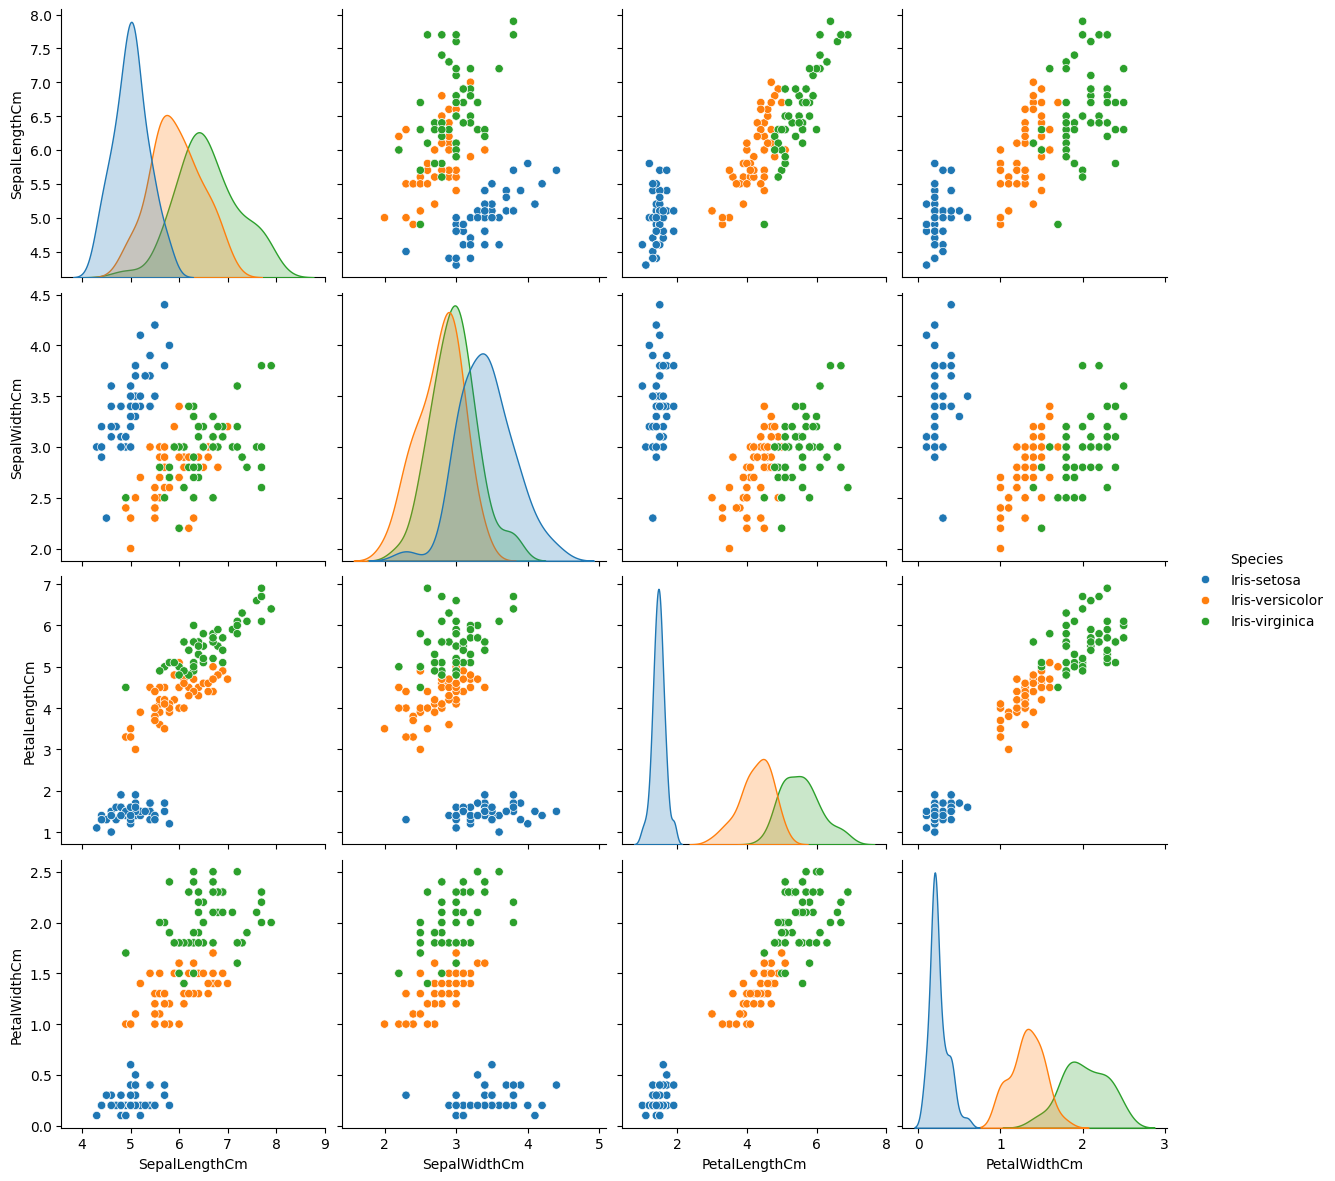

In [27]:
sns.pairplot(iris.drop("Id", axis=1), hue="Species", size=3)

# Contoh Pengerjaan Data WDBC

In [28]:
import pandas as pd
from sklearn.impute import KNNImputer


# 1. Data Understanding

### Pastikan Baca data Info nya terlebih dahulu

In [29]:
# Baca data
df = pd.read_csv("wdbc_modified.data.txt", header=None)

In [30]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,NaN,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,NaN,NaN,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,NaN,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
column_names = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

In [32]:
df.columns = column_names

In [33]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,NaN,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,NaN,NaN,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,NaN,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [34]:
df.isnull().sum()

id                          0
diagnosis                   0
radius_mean                37
texture_mean               36
perimeter_mean             34
area_mean                  29
smoothness_mean            25
compactness_mean           29
concavity_mean             36
concave_points_mean        22
symmetry_mean              22
fractal_dimension_mean     37
radius_se                  30
texture_se                 28
perimeter_se               34
area_se                    36
smoothness_se              23
compactness_se             18
concavity_se               25
concave_points_se          35
symmetry_se                36
fractal_dimension_se       28
radius_worst               26
texture_worst              30
perimeter_worst            30
area_worst                 25
smoothness_worst           29
compactness_worst          30
concavity_worst            32
concave_points_worst       31
symmetry_worst             24
fractal_dimension_worst    23
dtype: int64

In [35]:
df.isna().sum()

id                          0
diagnosis                   0
radius_mean                37
texture_mean               36
perimeter_mean             34
area_mean                  29
smoothness_mean            25
compactness_mean           29
concavity_mean             36
concave_points_mean        22
symmetry_mean              22
fractal_dimension_mean     37
radius_se                  30
texture_se                 28
perimeter_se               34
area_se                    36
smoothness_se              23
compactness_se             18
concavity_se               25
concave_points_se          35
symmetry_se                36
fractal_dimension_se       28
radius_worst               26
texture_worst              30
perimeter_worst            30
area_worst                 25
smoothness_worst           29
compactness_worst          30
concavity_worst            32
concave_points_worst       31
symmetry_worst             24
fractal_dimension_worst    23
dtype: int64

In [36]:
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [37]:
df["diagnosis"].nunique()

2

### Cek ada variabel aneh

In [38]:
# Cek ada berapa banyak tanda "aneh"
print((df == ';').sum().sum())

0


In [39]:
# Buat kolom baru untuk kategori diagnosis
df["diagnosis_num"] = df["diagnosis"].map({"M": 1, "B": 0})

In [40]:
df["diagnosis_num"] = df["diagnosis_num"].astype(int)

# EDA Sebelum Imputasi

In [41]:
# Pisahkan kolom Numerik 
df_num = df.drop(columns=["id", "diagnosis", "diagnosis_num"]).apply(pd.to_numeric, errors="coerce")

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

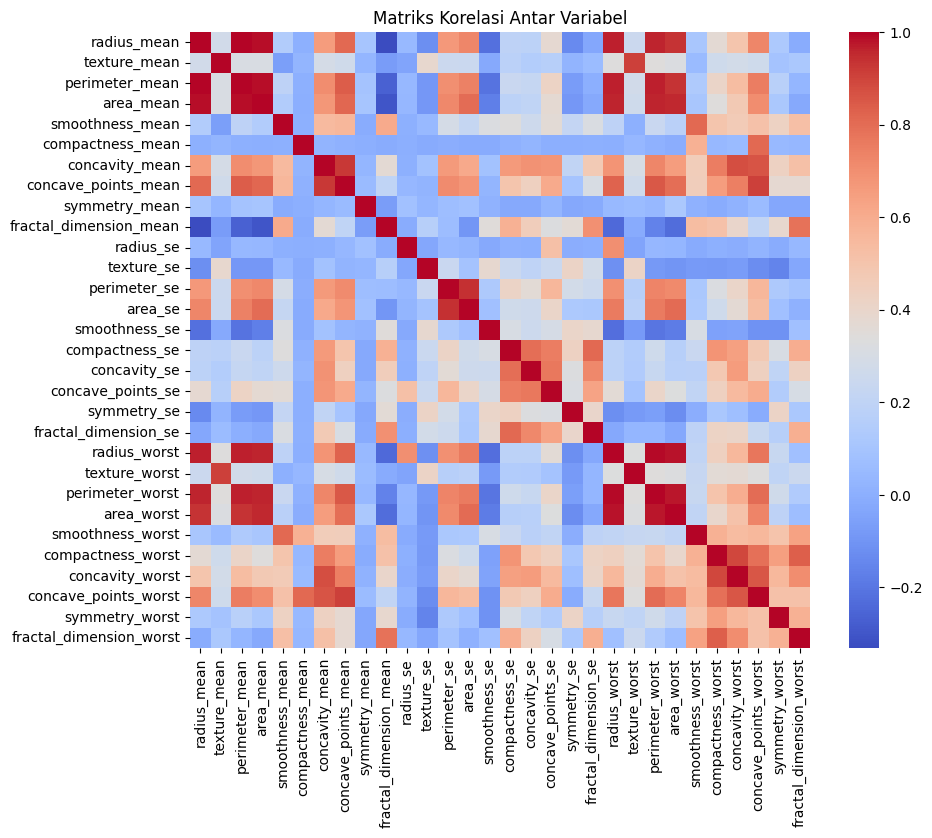

In [43]:
corr = df_num.corr()  # matriks korelasi
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Matriks Korelasi Antar Variabel")
plt.show()

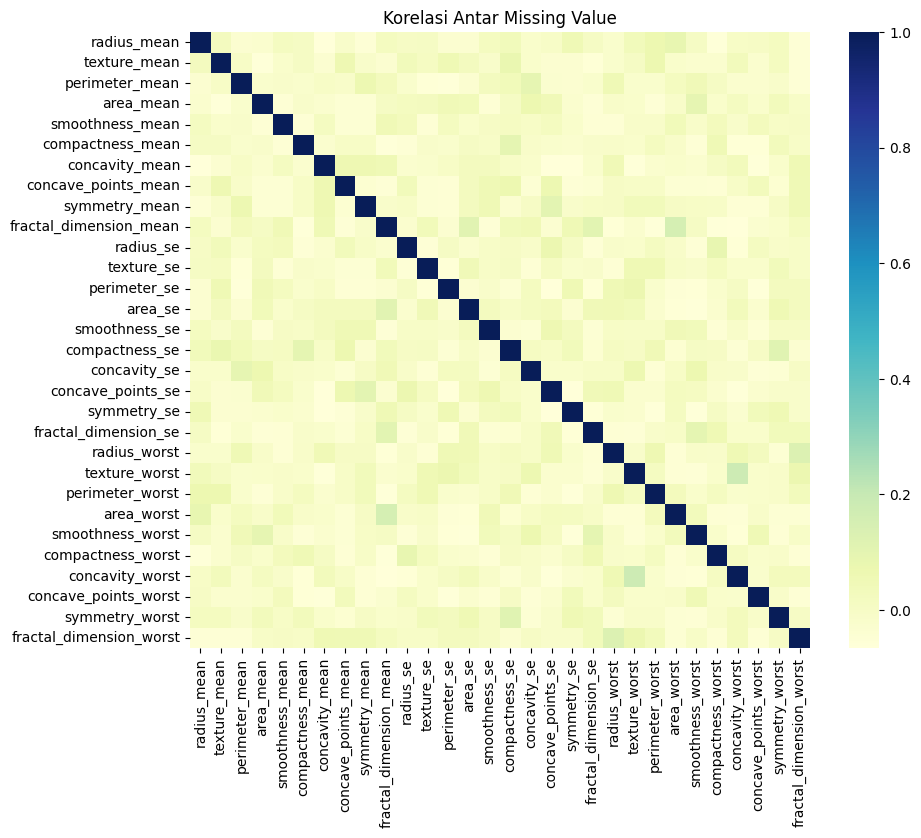

In [44]:
# Buat mask missing value (1 = NaN, 0 = ada nilai)
missing_mask = df_num.isna().astype(int)

# Hitung korelasi antar missing value
corr_missing = missing_mask.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_missing, cmap="YlGnBu")
plt.title("Korelasi Antar Missing Value")
plt.show()

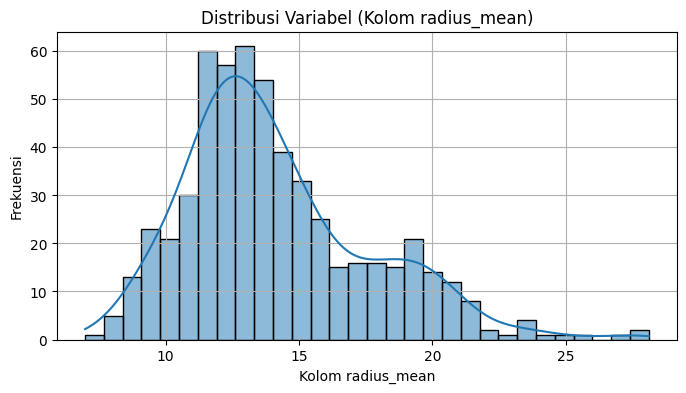

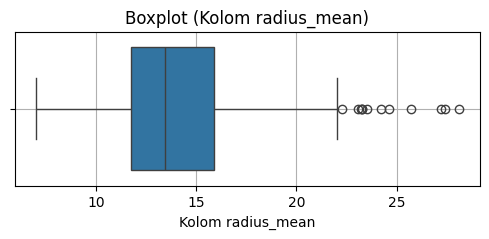

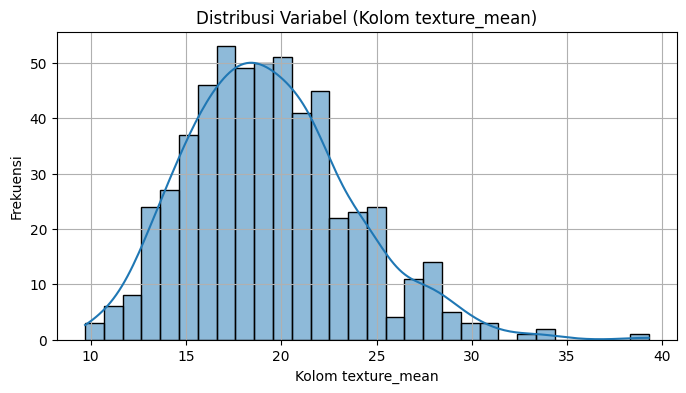

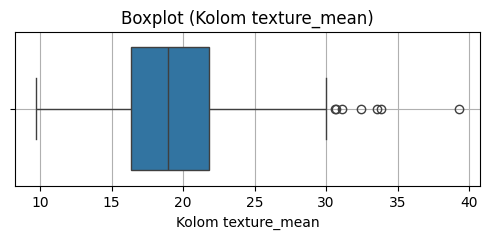

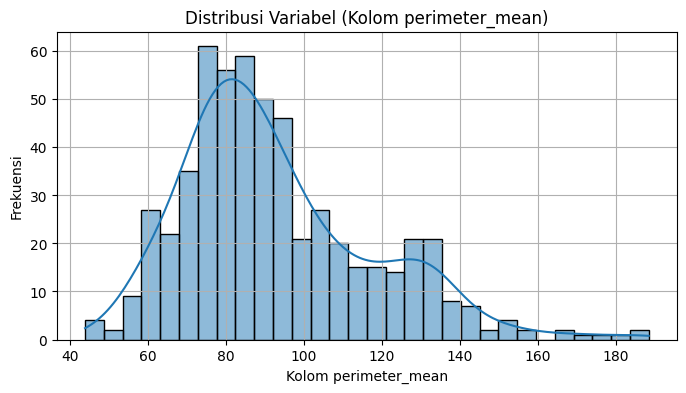

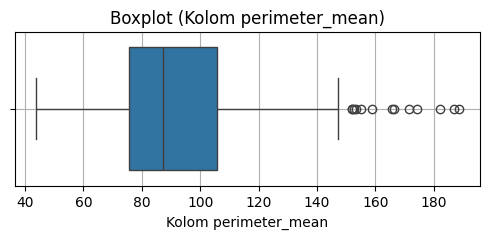

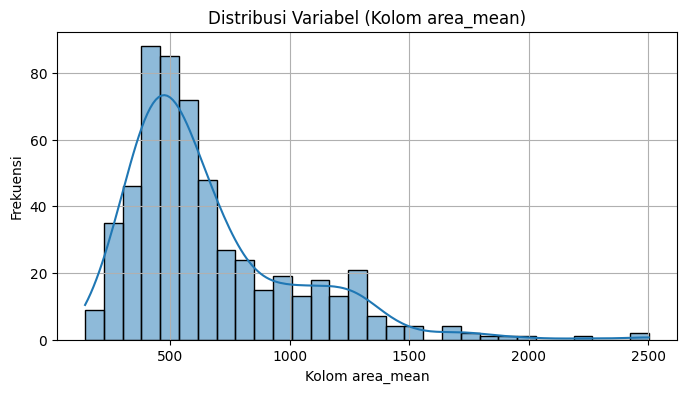

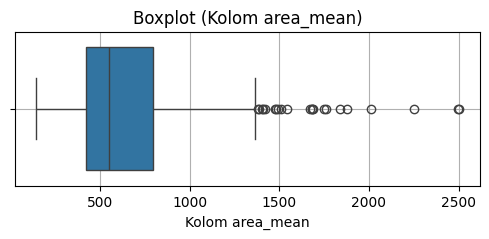

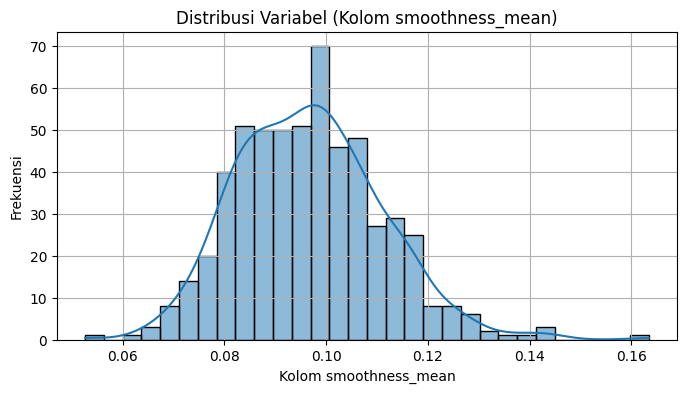

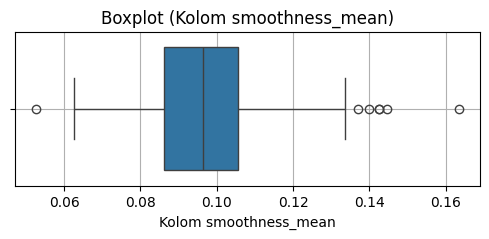

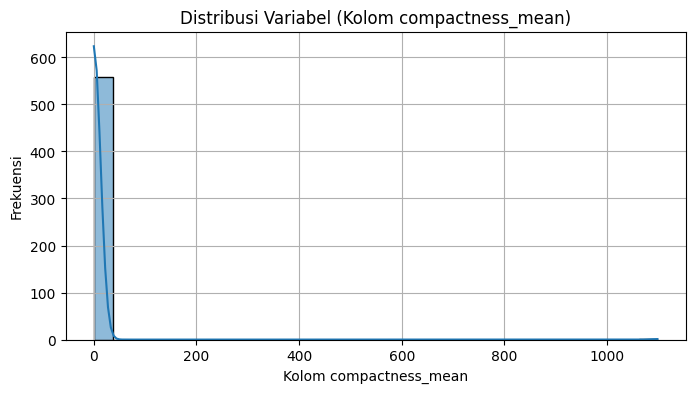

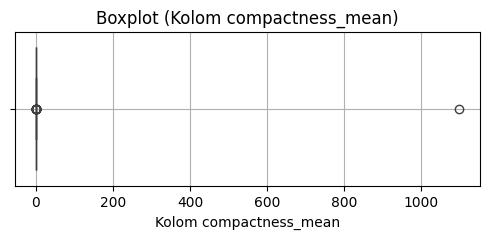

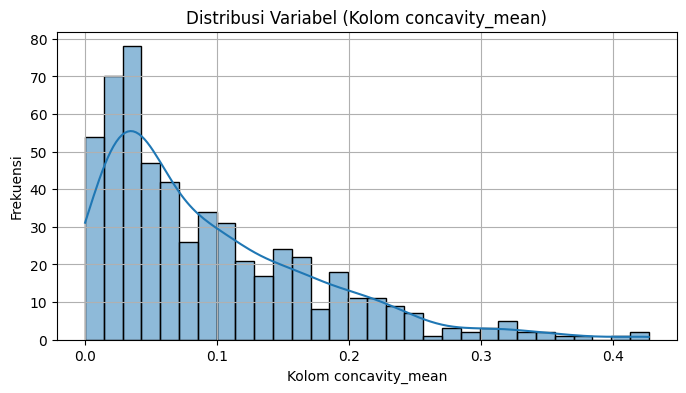

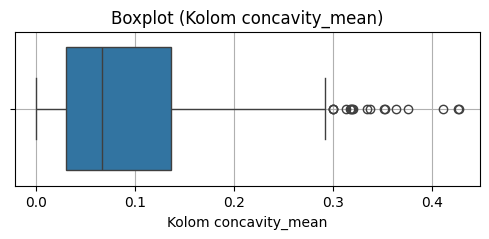

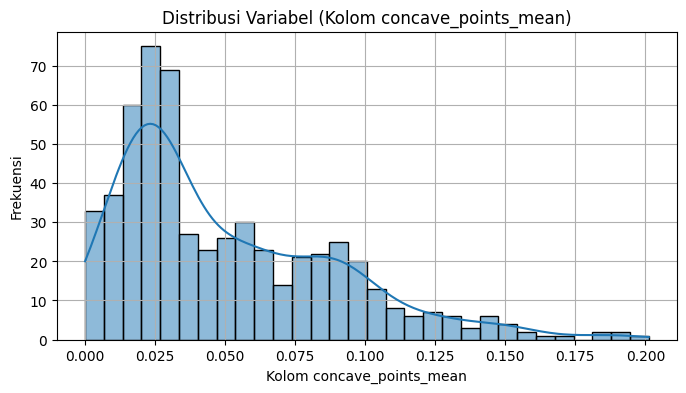

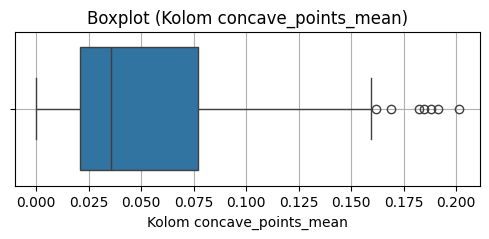

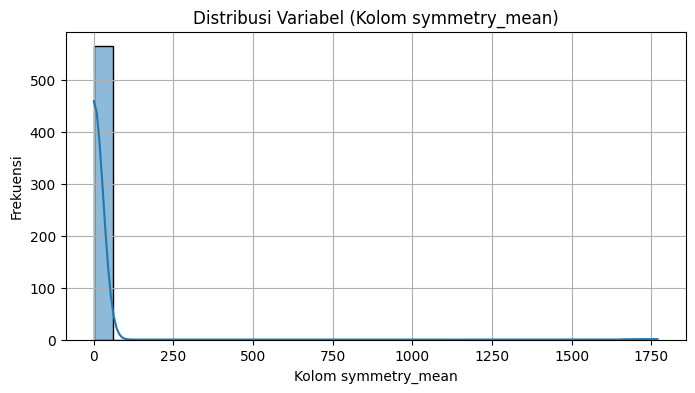

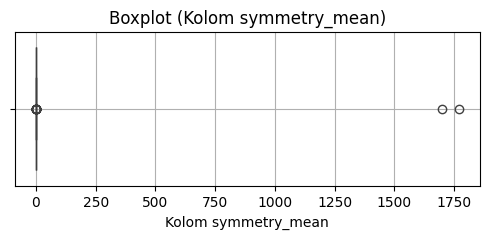

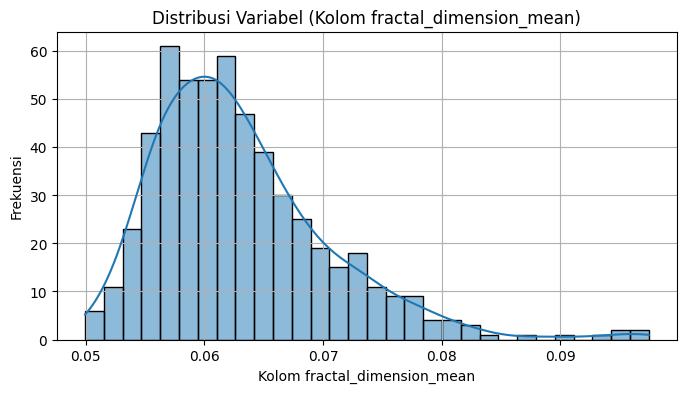

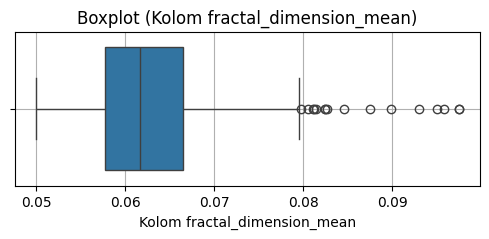

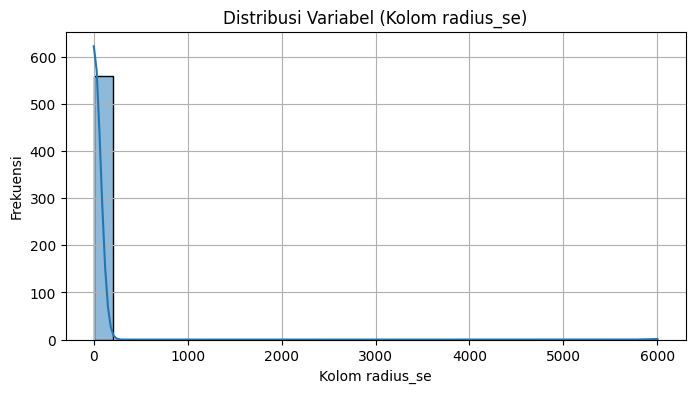

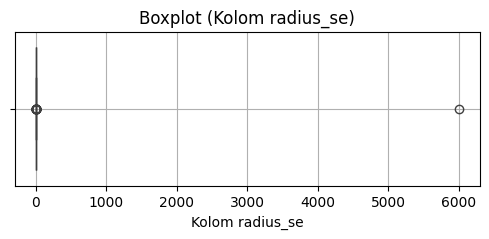

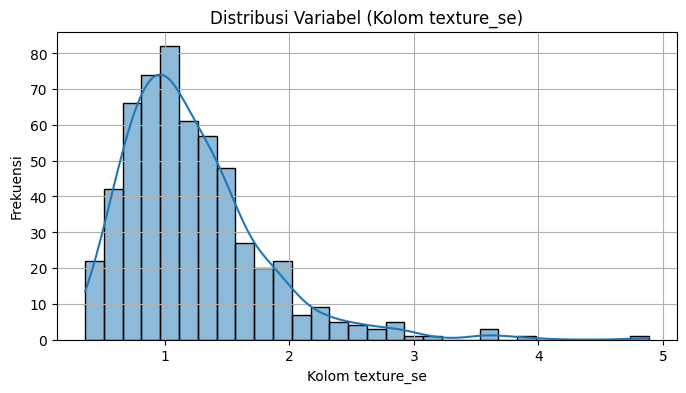

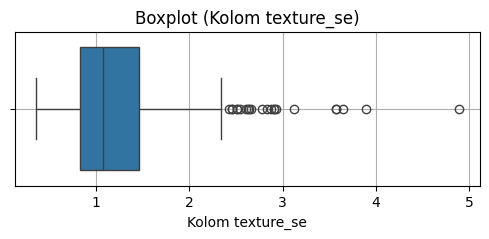

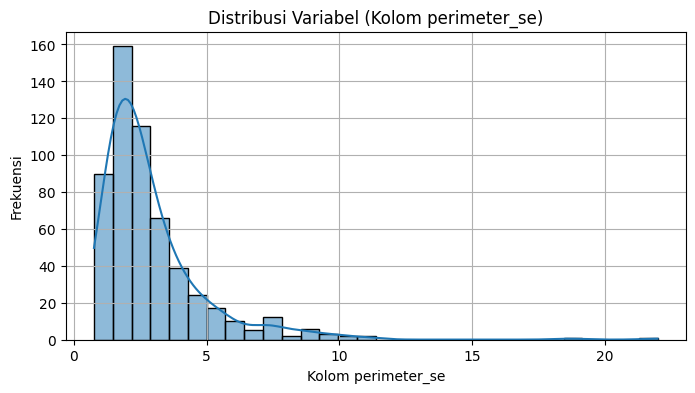

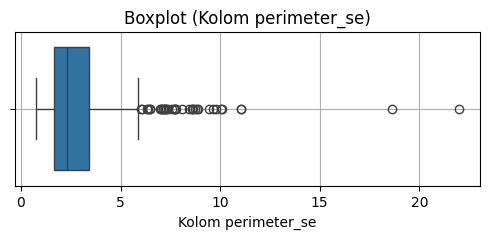

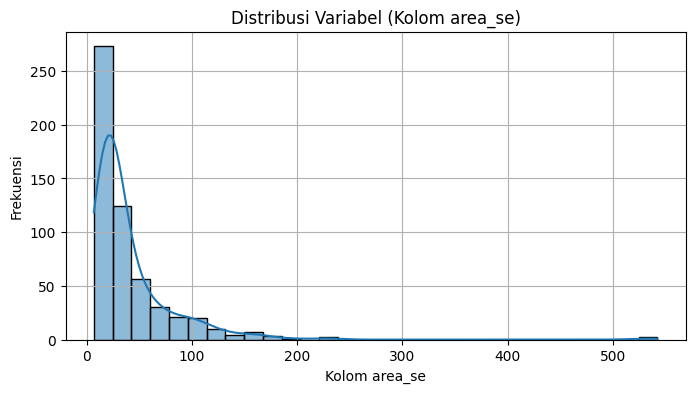

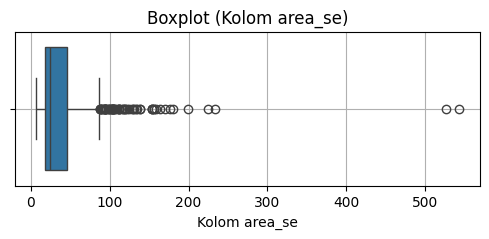

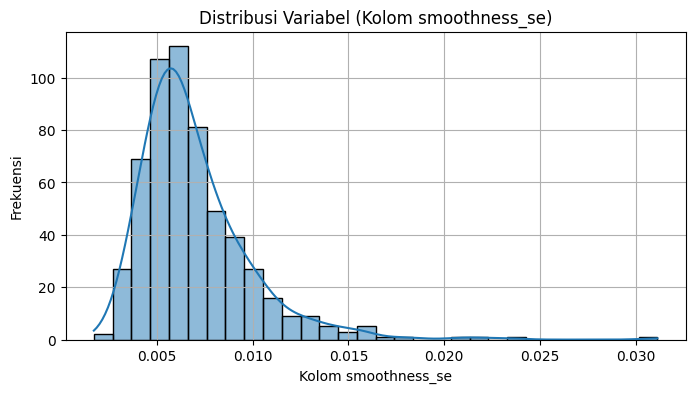

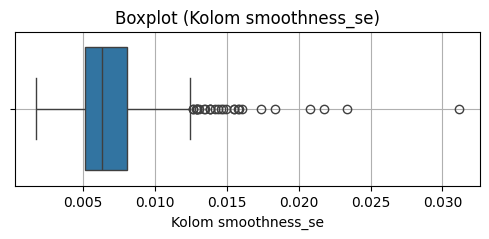

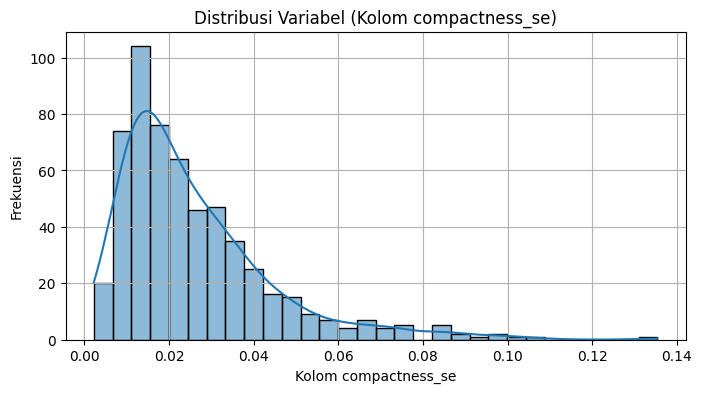

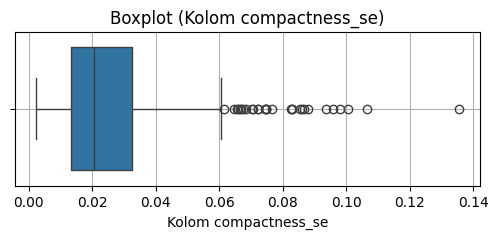

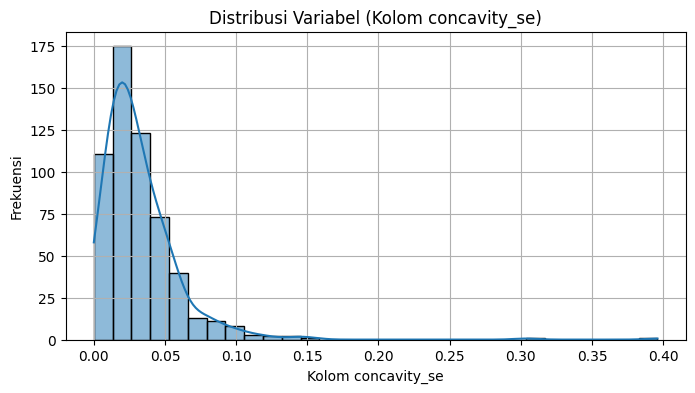

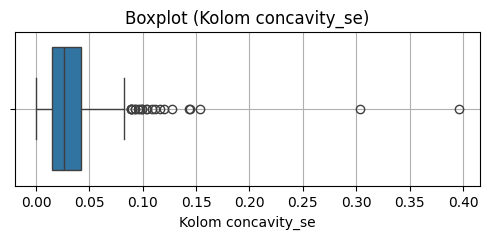

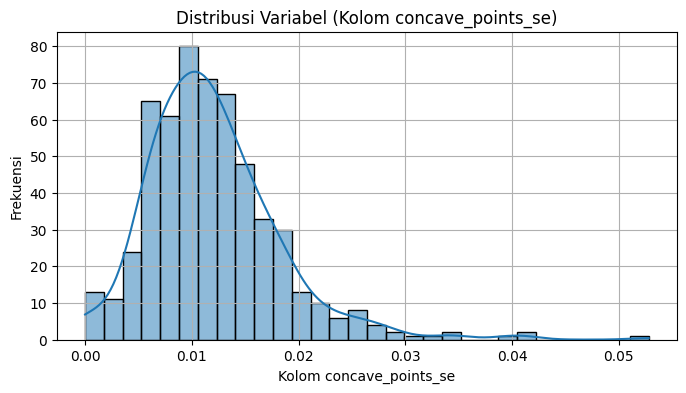

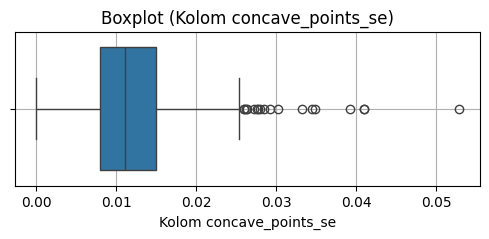

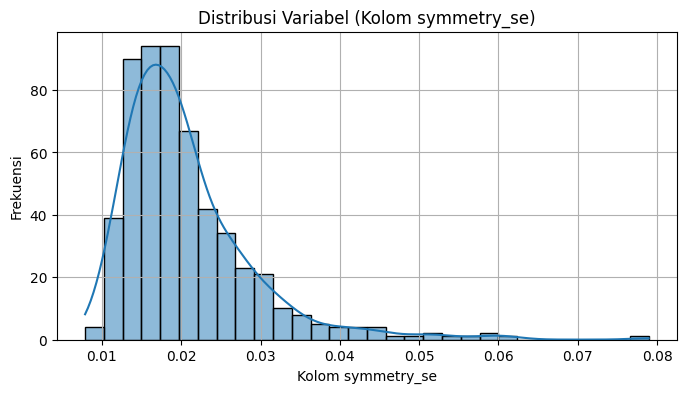

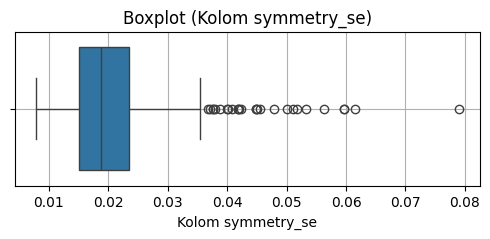

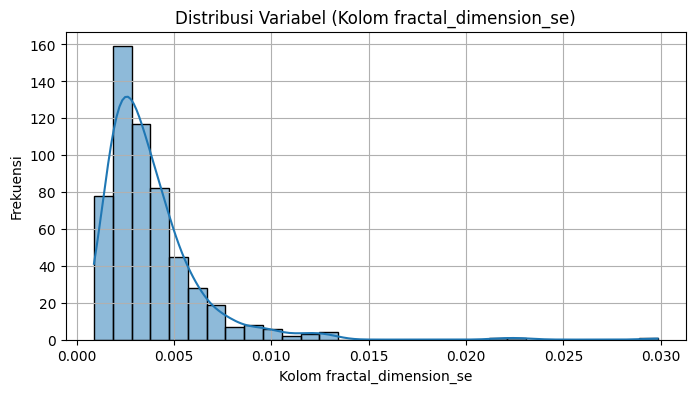

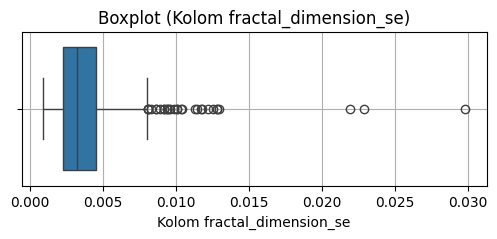

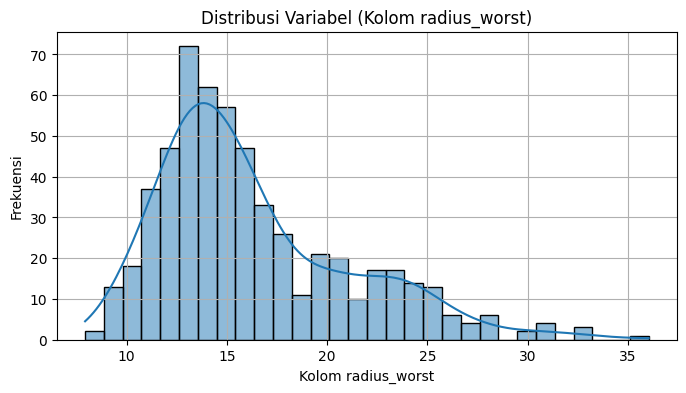

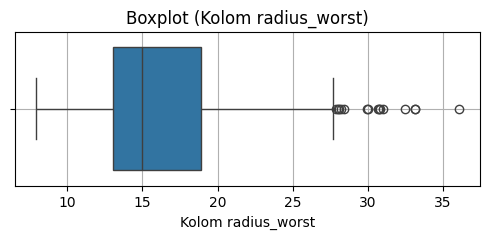

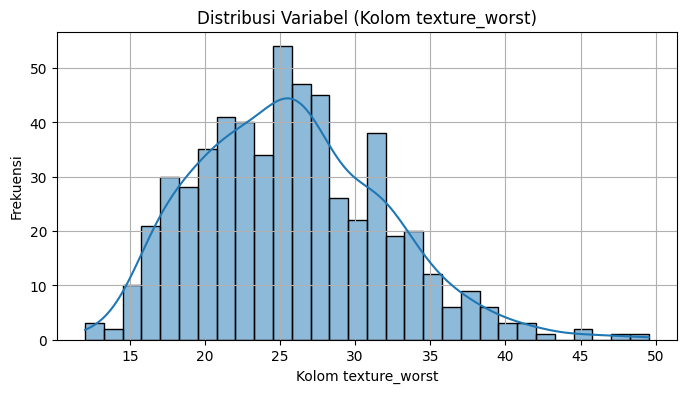

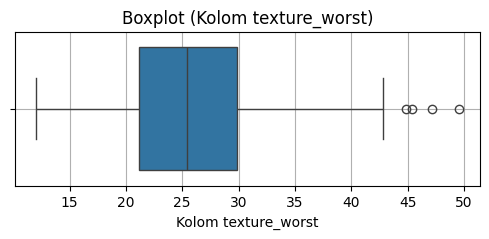

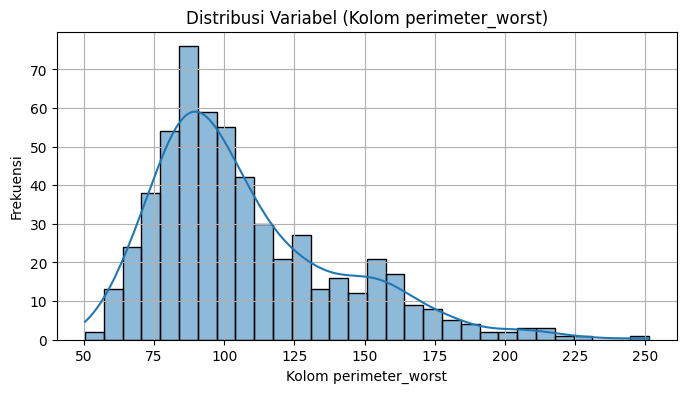

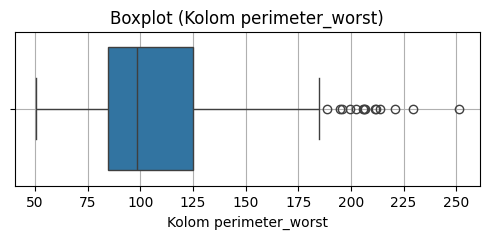

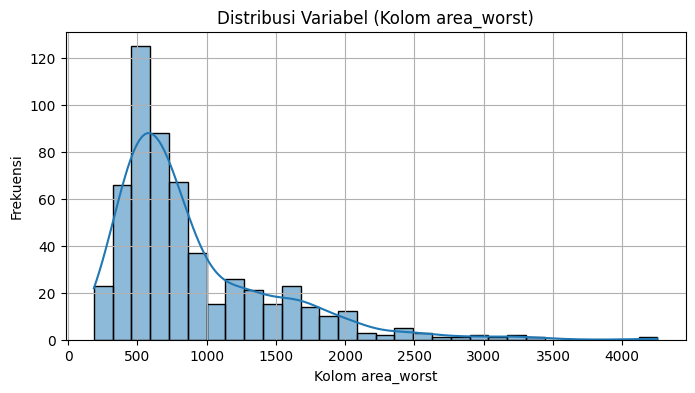

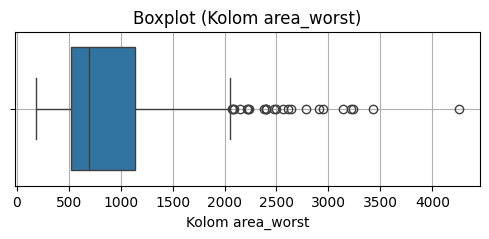

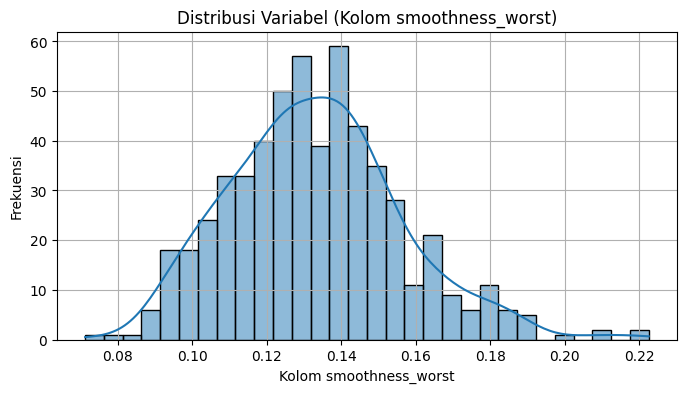

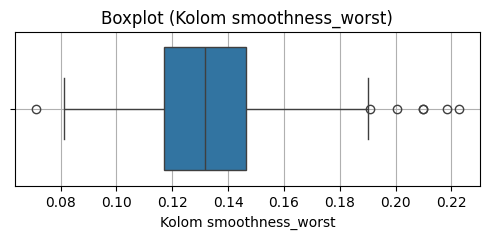

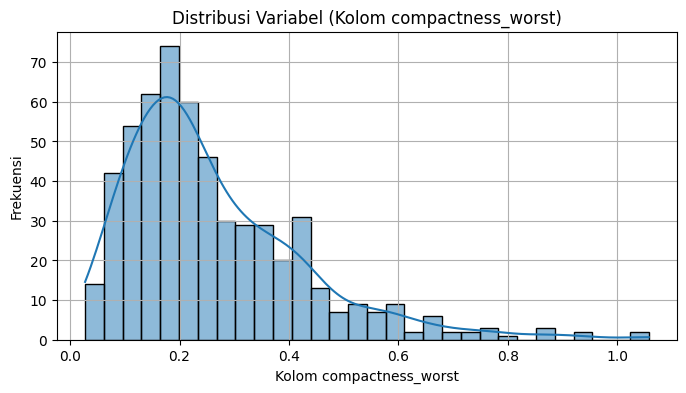

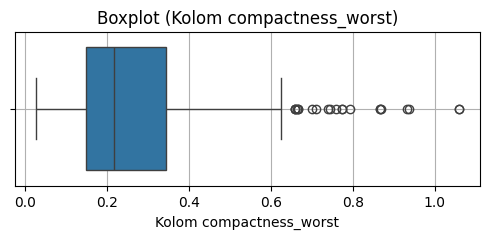

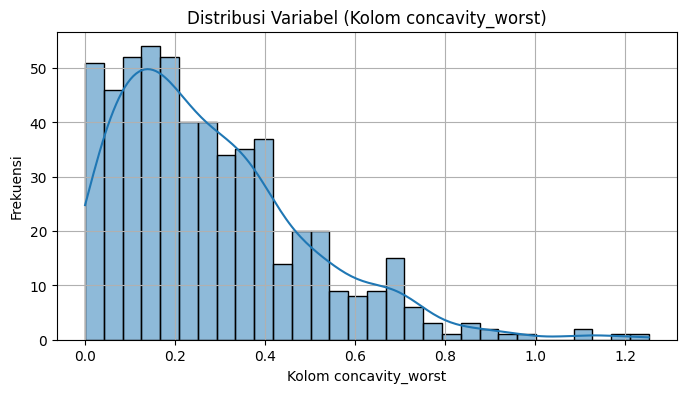

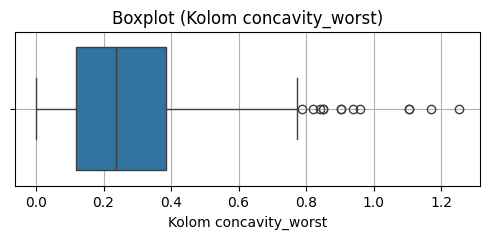

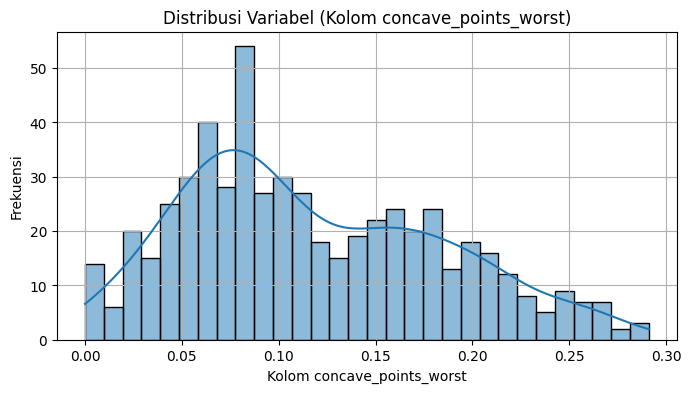

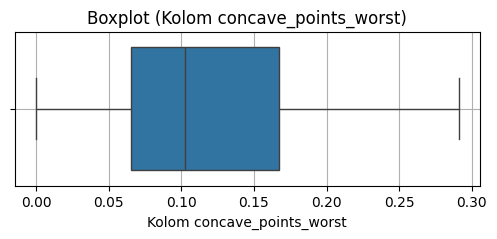

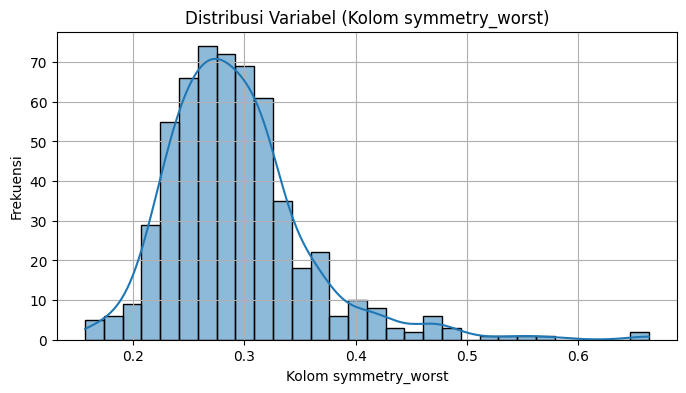

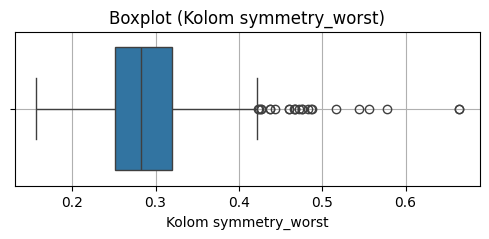

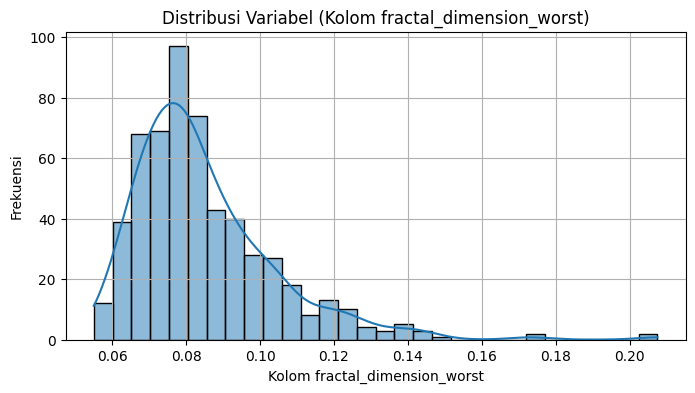

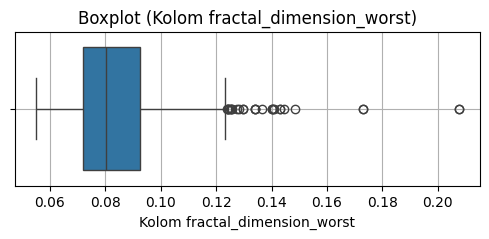

In [45]:
# Buat histogram dan boxplot untuk semua kolom numerik
for col in df_num.columns:
    data_col = df_num[col].dropna()
    if not data_col.empty:
        # Plot distribusi (histogram + KDE)
        plt.figure(figsize=(8, 4))
        sns.histplot(data_col, kde=True, bins=30)
        plt.title(f"Distribusi Variabel (Kolom {col})")
        plt.xlabel(f"Kolom {col}")
        plt.ylabel("Frekuensi")
        plt.grid(True)
        plt.show()
        
        # Plot boxplot
        plt.figure(figsize=(6, 2))
        sns.boxplot(x=data_col, orient='h')
        plt.title(f"Boxplot (Kolom {col})")
        plt.xlabel(f"Kolom {col}")
        plt.grid(True)
        plt.show()

# Imputasi Data

Disini aku pilih imputasi menggunakan knn karena:
1. Pola missing acak
2. Korelasi antar fitur sebagian kuat, jadi KNN masih bisa meniru hubungan lokal.
3. Distribusi skew dan ada outlier, Iterative dengan default baynesian ridge (sensitif terhadap outlier)

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
# Normalisasi (standarisasi ke mean=0, std=1)
scaler = StandardScaler()
scaled = scaler.fit_transform(df_num)

In [48]:
# Inisialisasi dan lakukan imputasi KNN
imputer = KNNImputer(n_neighbors=5)
imputed_scaled = imputer.fit_transform(scaled)

In [49]:
# Kembalikan ke skala asli
imputed_original = scaler.inverse_transform(imputed_scaled)
df_imputed = pd.DataFrame(imputed_original, columns=df_num.columns)

In [50]:
# Gabungkan kembali dengan kolom id & diagnosis
df_final = pd.concat([df[["id", "diagnosis", "diagnosis_num"]], df_imputed], axis=1)

In [51]:
df_final.head()

,id,diagnosis,diagnosis_num,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,1,17.99,10.380,122.80,981.02,0.11840,0.27760,0.3001,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,1,18.82,20.384,132.90,1326.00,0.08474,0.07864,0.0869,...,24.99,23.41,154.88,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,1,19.69,21.250,130.00,1203.00,0.10960,0.15990,0.1974,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,1,11.42,20.380,77.58,386.10,0.14250,0.28390,0.2414,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,1,20.29,14.340,135.10,1297.00,0.10030,0.13280,0.1980,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## EDA setelah Imputasi

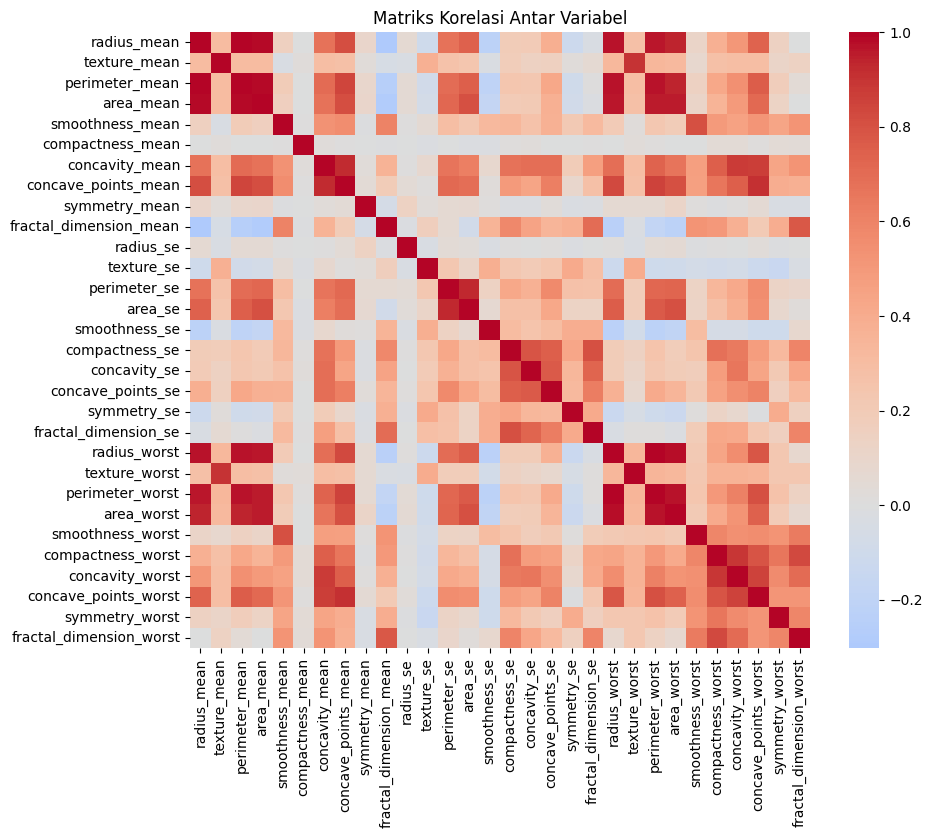

In [52]:
# 2Korelasi antar fitur
plt.figure(figsize=(10,8))
sns.heatmap(df_imputed.corr(), cmap="coolwarm", center=0)
plt.title("Matriks Korelasi Antar Variabel")
plt.show()

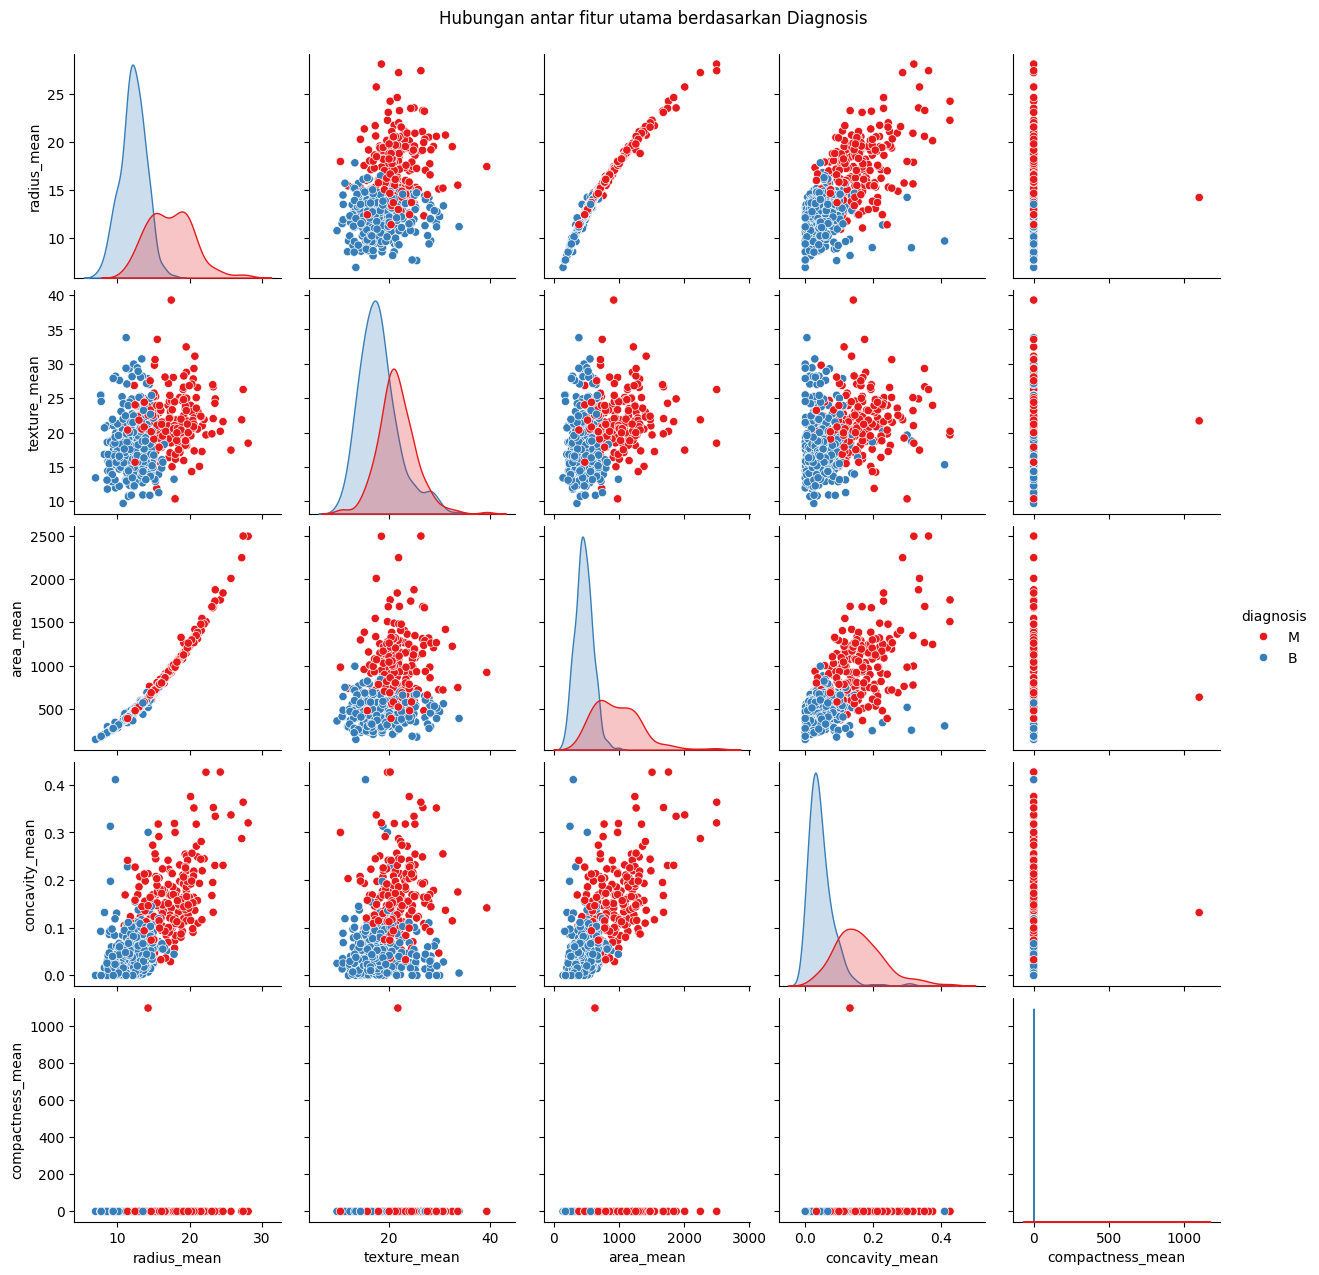

In [53]:
# Pairplot fitur paling berpengaruh
top_features = ["radius_mean", "texture_mean", "area_mean", "concavity_mean", "compactness_mean"]
sns.pairplot(df_final[top_features + ["diagnosis"]], hue="diagnosis", diag_kind="kde", palette="Set1")
plt.suptitle("Hubungan antar fitur utama berdasarkan Diagnosis", y=1.02)
plt.show()

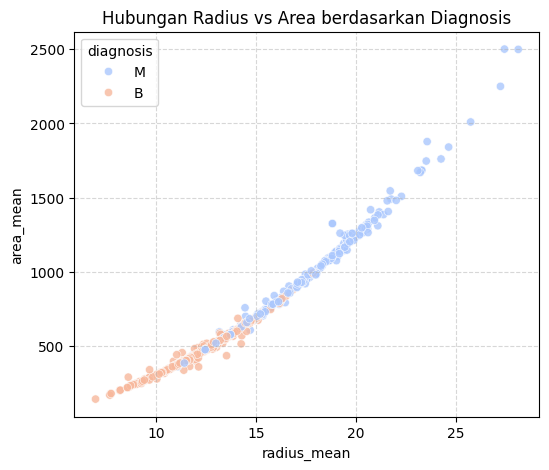

In [54]:
# Visualisasi hubungan dua fitur yang paling korelatif
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_final, x="radius_mean", y="area_mean", hue="diagnosis", palette="coolwarm", alpha=0.8)
plt.title("Hubungan Radius vs Area berdasarkan Diagnosis")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Cleaning Data 2

In [55]:
data = {'Matkul':['Mat','Mat','Fis','Fis','Kim','Kim'],
        'Name':['Adi','Edo','Lia','Lea','Rio','Ola'],
        'Nilai':['90','60','','78','94 poin','86']}

df = pd.DataFrame(data)
gender = pd.DataFrame({'Gender':['L','L','P','P','L','P']})

In [56]:
# Ubah '' jadi NaN
df['Nilai'] = df['Nilai'].replace('', np.nan)

In [57]:
df['Nilai'] = df['Nilai'].str.replace(' poin', '').astype(float)

In [58]:
# Pakai concat
df_append = pd.concat([df, gender])  # axis=0 default (rows)
print(df_append)

  Matkul Name  Nilai Gender
0    Mat  Adi   90.0    NaN
1    Mat  Edo   60.0    NaN
2    Fis  Lia    NaN    NaN
3    Fis  Lea   78.0    NaN
4    Kim  Rio   94.0    NaN
5    Kim  Ola   86.0    NaN
0    NaN  NaN    NaN      L
1    NaN  NaN    NaN      L
2    NaN  NaN    NaN      P
3    NaN  NaN    NaN      P
4    NaN  NaN    NaN      L
5    NaN  NaN    NaN      P


In [59]:
# Pakai concat
df_append = pd.concat([df, gender], axis=1)  # axis=1 (colomn)
print(df_append)

  Matkul Name  Nilai Gender
0    Mat  Adi   90.0      L
1    Mat  Edo   60.0      L
2    Fis  Lia    NaN      P
3    Fis  Lea   78.0      P
4    Kim  Rio   94.0      L
5    Kim  Ola   86.0      P


## Cleaning menggunakan bfill dan ffill

bfill, dan ffill biasanya digunakan untuk time series

In [60]:
#Forward
df_ffill = df_append.fillna(method='ffill', inplace=True)
df_ffill

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_26631/4048251653.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df_append.fillna(method='ffill', inplace=True)


In [61]:
#Backward
df_bfill = df.fillna(method='bfill', inplace=True)

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_26631/3984588421.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method='bfill', inplace=True)


### Join

In [62]:
df_nilai = pd.DataFrame({
    'Name': ['Adi', 'Edo', 'Lia', 'Lea', 'Rio', 'Ola', 'Tio'],
    'Matkul': ['Mat', 'Mat', 'Fis', 'Fis', 'Kim', 'Kim', 'Bio'],
    'Nilai': [90, 70, 86, 78, 94, 86, 60]
})

df_mahasiswa = pd.DataFrame({
    'Name': ['Adi', 'Edo', 'Lia', 'Lea', 'Rio', 'Ola', 'Zee'],
    'Gender': ['L', 'L', 'P', 'P', 'L', 'P', 'P'],
    'Kelas': ['A', 'A', 'B', 'B', 'A', 'C', 'C']
})

### INNER JOIN

In [63]:
# hanya data yang muncul di kedua tabel
df_inner = pd.merge(df_nilai, df_mahasiswa, on='Name', how='inner')
print(df_inner, '\n')

  Name Matkul  Nilai Gender Kelas
0  Adi    Mat     90      L     A
1  Edo    Mat     70      L     A
2  Lia    Fis     86      P     B
3  Lea    Fis     78      P     B
4  Rio    Kim     94      L     A
5  Ola    Kim     86      P     C 



### LEFT JOIN

In [64]:
# semua dari df_nilai, tambah info mahasiswa kalau ada
df_left = pd.merge(df_nilai, df_mahasiswa, on='Name', how='left')
print(df_left, '\n')

  Name Matkul  Nilai Gender Kelas
0  Adi    Mat     90      L     A
1  Edo    Mat     70      L     A
2  Lia    Fis     86      P     B
3  Lea    Fis     78      P     B
4  Rio    Kim     94      L     A
5  Ola    Kim     86      P     C
6  Tio    Bio     60    NaN   NaN 



### RIGHT JOIN

In [65]:
# semua dari df_mahasiswa, tambah nilai kalau ada
df_right = pd.merge(df_nilai, df_mahasiswa, on='Name', how='right')
print("=== RIGHT JOIN ===")
print(df_right, '\n')

=== RIGHT JOIN ===
  Name Matkul  Nilai Gender Kelas
0  Adi    Mat   90.0      L     A
1  Edo    Mat   70.0      L     A
2  Lia    Fis   86.0      P     B
3  Lea    Fis   78.0      P     B
4  Rio    Kim   94.0      L     A
5  Ola    Kim   86.0      P     C
6  Zee    NaN    NaN      P     C 



### OUTER JOIN

In [66]:
# gabungkan semuanya (seperti FULL OUTER JOIN di SQL)
df_outer = pd.merge(df_nilai, df_mahasiswa, on='Name', how='outer', indicator=True)
print(df_outer, '\n')

  Name Matkul  Nilai Gender Kelas      _merge
0  Adi    Mat   90.0      L     A        both
1  Edo    Mat   70.0      L     A        both
2  Lea    Fis   78.0      P     B        both
3  Lia    Fis   86.0      P     B        both
4  Ola    Kim   86.0      P     C        both
5  Rio    Kim   94.0      L     A        both
6  Tio    Bio   60.0    NaN   NaN   left_only
7  Zee    NaN    NaN      P     C  right_only 



# Fuzzy Matching & Ratio

## Pengertian
**Fuzzy Matching** adalah metode untuk membandingkan dua teks yang mirip tapi tidak harus sama persis.  
Biasanya digunakan untuk:
- Mendeteksi typo atau kesalahan penulisan.
- Mencocokkan nama, alamat, atau data ganda.

In [67]:
from rapidfuzz import fuzz, process

# Daftar nama di database
data_nama = ["Mirza Akmal", "M. Akmal Norman", "Akmal N", "Akmall", "Norman M"]

# Nama input yang mau dicocokkan
input_nama = "Mirzariel Akmal Norman"

# Hitung Fuzzy Ratio untuk masing-masing
for nama in data_nama:
    ratio = fuzz.ratio(input_nama, nama)
    print(f"{nama:<20} → Fuzzy Ratio: {ratio:.2f}")


Mirza Akmal          → Fuzzy Ratio: 66.67
M. Akmal Norman      → Fuzzy Ratio: 75.68
Akmal N              → Fuzzy Ratio: 48.28
Akmall               → Fuzzy Ratio: 35.71
Norman M             → Fuzzy Ratio: 40.00


In [68]:
from fuzzywuzzy import fuzz

# Dua teks yang mirip tapi tidak identik
a = "Mirza Akmal Norman"
b = "M. Akmal Norman"

/opt/miniconda3/envs/datminW2/lib/python3.10/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [69]:
# Bandingkan kemiripannya (0–100)
ratio = fuzz.ratio(a, b)
print(f"Fuzzy Ratio: {ratio}")

Fuzzy Ratio: 85


In [70]:
# Variasi
print("Ratio biasa:", fuzz.ratio(a, b))
print("Partial ratio:", fuzz.partial_ratio(a, b))             # Cocok sebagian teks
print("Token sort ratio:", fuzz.token_sort_ratio(a, b))       # Abaikan urutan kata
print("Token set ratio:", fuzz.token_set_ratio(a, b))         # Gabungkan kata unik


Ratio biasa: 85
Partial ratio: 87
Token sort ratio: 88
Token set ratio: 92


| Fungsi             | Fokus utama            | Urutan kata        | Cocok untuk                                   |
| ------------------ | ---------------------- | ------------------ | --------------------------------------------- |
| `ratio`            | Huruf per huruf        | Diperhatikan       | Data teks rapi                                |
| `partial_ratio`    | Pencocokan sebagian    | Diperhatikan       | Substring / teks panjang                      |
| `token_sort_ratio` | Urutan kata diabaikan  | Tidak diperhatikan | Nama/kalimat terbalik                         |
| `token_set_ratio`  | Kata unik dibandingkan | Tidak diperhatikan | Teks dengan kata duplikat atau tambahan kecil |
